# Simple PhysioNet metrics

This notebook contains a simple set of metrics derived from data extracted from the PhysioNet database.

NOTES:
- Add the following columns to data:
  - credentialing datetime
  - 

## Recommended repository

PhysioNet is recommended by:

- Scientific Data: https://www.nature.com/sdata/policies/repositories
- PLOS Biology: https://journals.plos.org/plosbiology/s/recommended-repositories
- NUS: https://libguides.nus.edu.sg/rdm/selected_dr
- NeurIPS: https://neurips.cc/Conferences/2023/CallForDatasetsBenchmarks
- Springer Nature: https://www.springernature.com/gp/authors/research-data-policy/health-sciences-repositories/12327108
- PLOS One: https://journals.plos.org/plosone/s/recommended-repositories#loc-biomedical-sciences
- Elsevier: https://admin1.journals.elsevier.com/

## Datathons

List of datathons:  
https://docs.google.com/document/d/19x5sJFIsbJYAlTC6yegyDio_OhEIRV9Bz0GV57WpQi0/

## Setup

In [228]:
import os
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
from tableone import TableOne

In [229]:
# Set the aesthetic style of the plots
sns.set(style="whitegrid")
fig_axis_fontsize = 12
fig_title_fontsize = 12
fig_bar_color = "dodgerblue"
fig_edgecolor = "black"

In [230]:
# path to datasets
base_path = os.path.join("..", "data", "physionet")

In [231]:
# Custom function to parse the datetime
def parse_publish_date(date_str):
    try:
        # Try the format with microseconds first
        return datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S.%f%z")
    except ValueError:
        # If that fails, try the format without microseconds
        return datetime.strptime(date_str, "%Y-%m-%d %H:%M:%S%z")

## Load data

Loading data for analysis, including:

- users
- projects
- historical data (pre-2020)

In [232]:
# iterate folder
for file in os.listdir(base_path):
    print(file)

users.csv
publishing_email_last_year.xlsx
README.md
publishing_email_last_year.csv
users_standardized.csv
projects.csv


In [237]:
users = pd.read_csv(os.path.join(base_path, "users.csv"), low_memory=False)

# Convert date columns to date type
users['join_date'] = pd.to_datetime(users['join_date'], format="%Y-%m-%d")
# users = users.with_columns(pl.col("join_date").str.strptime(pl.Date, "%Y-%m-%d"))

users.head(3)

,user_id,username,join_date,last_login,registration_ip,is_active_user,primary_email,all_emails,first_names,last_name,...,credentialing_job_title,credentialing_city,credentialing_state_or_province,credentialing_country,credentialing_webpage,credentialing_reference_name,credentialing_reference_email,credentialing_reference_org,credentialing_reference_response,credentialing_research_summary
0,2,ftorres,2019-01-11,2024-05-30 23:51:55.929525+00:00,NaN,True,ftf.dummy@gmail.com,"ftorres@physionet.org, ftf.dummy@gmail.com",Felipe III,Torres Fábregas,...,TEST,TEST,TEST,US,NaN,TEST,felipe.torres.cs@gmail.com,NaN,NaN,TEST
1,6,tompollard,2019-02-19,2024-08-01 15:22:27.844114+00:00,NaN,True,tpollard@mit.edu,"tpollard@mit.edu, tompollardx@gmail.com",Tom,Pollard,...,Research Scientist,Somerville,MA,US,NaN,Tom Pollard,tpollard@mit.edu,NaN,Me.,Laboratory for Computational Physiology
2,8,benjamin,2019-02-21,2024-08-06 20:16:01.888720+00:00,NaN,True,bmoody@mit.edu,"bmoody@mit.edu, benjaminmoody+test123@gmail.co...",Benjamin,Moody,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [238]:
projects = pd.read_csv(os.path.join(base_path, "projects.csv"), low_memory=False)

# Convert date columns to date type
# projects = projects.with_columns(pl.col("publish_date").str.to_datetime("%Y-%m-%d %H:%M:%S%.f%z", strict=False))
# projects['publish_date'] = pd.to_datetime(projects['publish_date'], errors='coerce')
# projects['publish_date'] = pd.to_datetime(projects['publish_date'], errors='coerce')
projects['publish_date'] = projects['publish_date'].apply(parse_publish_date).dt.date

# projects[projects.publish_date == pd.NaT]
projects.head()

,project_id,core_project_id,project_slug,version,publish_date,has_other_versions,version_order,is_latest_version,project_doi,core_project_doi,...,short_description,access_policy,license,data_use_agreement,project_home_page,ethics_statement,corresponding_author_id,author_ids,associated_paper,associated_paper_url
0,292,cbf2f243-9315-40e4-8f9f-a1dd61159373,bhi-2018-challenge,1.0,2018-02-05,False,0,True,10.13026/v1jk-ax96,10.13026/5bhj-nf42,...,A challenge to explore real clinical questions...,0,MIT License,NaN,https://bhi-bsn.embs.org/2018/,NaN,22.0,"22, 21, 23",NaN,NaN
1,170,bb5406a7-92a3-4e05-b5e0-0b08ee0d078c,adfecgdb,1.0.0,2012-08-09,False,0,True,10.13026/C2RP4B,NaN,...,Multichannel fetal electrocardiogram recording...,0,Open Data Commons Attribution License v1.0,NaN,NaN,NaN,NaN,NaN,"Jezewski J, Matonia A, Kupka T, Roj D, Czabans...",http://www.degruyter.com/view/j/bmte.ahead-of-...
2,540,3662aefa-49a8-4cf9-8a97-1968ffd0c2d4,brazilian-ophthalmological,1.0.0,2023-03-08,False,0,True,10.13026/xcxw-8198,10.13026/z9zv-g542,...,This is the first Brazilian Multilabel Ophthal...,2,PhysioNet Credentialed Health Data License 1.5.0,PhysioNet Credentialed Health Data Use Agreeme...,NaN,This project was approved by the Sao Paulo Fed...,1473.0,"1473, 1469, 1470, 1474, 1468, 1475, 1472, 1471",NaN,NaN
3,260,3471633f-e83e-4772-beaf-c67ea5dee68f,rcvsim,1.0.0,2001-09-19,False,0,True,NaN,NaN,...,NaN,0,Open Data Commons Attribution License v1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,624,dc177b77-cf57-4f31-982f-c902ecff106e,perg-ioba-dataset,1.0.0,2024-01-19,False,0,True,10.13026/d24m-w054,10.13026/2t6a-xq52,...,336 CSV records with 1354 PERG responses (micr...,0,Open Data Commons Attribution License v1.0,NaN,NaN,The data were collected during clinical activi...,1993.0,"1993, 1996, 1995, 1997, 1994",NaN,NaN


## Metrics

Extract simple metrics from the user and project data.

### Number of new users over time

In [240]:
# Convert 'join_date' to datetime if it's not already
users['join_date'] = pd.to_datetime(users['join_date'], errors='coerce')

# Extract the year from 'join_date' and create a new column 'year'
users['year'] = users['join_date'].dt.year

# Group by 'year' and count the number of users per year
users_per_year = users.groupby('year').agg(count=('user_id', 'size')).reset_index()

users_per_year.head(5)

,year,count
0,2019,6773
1,2020,15461
2,2021,18536
3,2022,21289
4,2023,29237


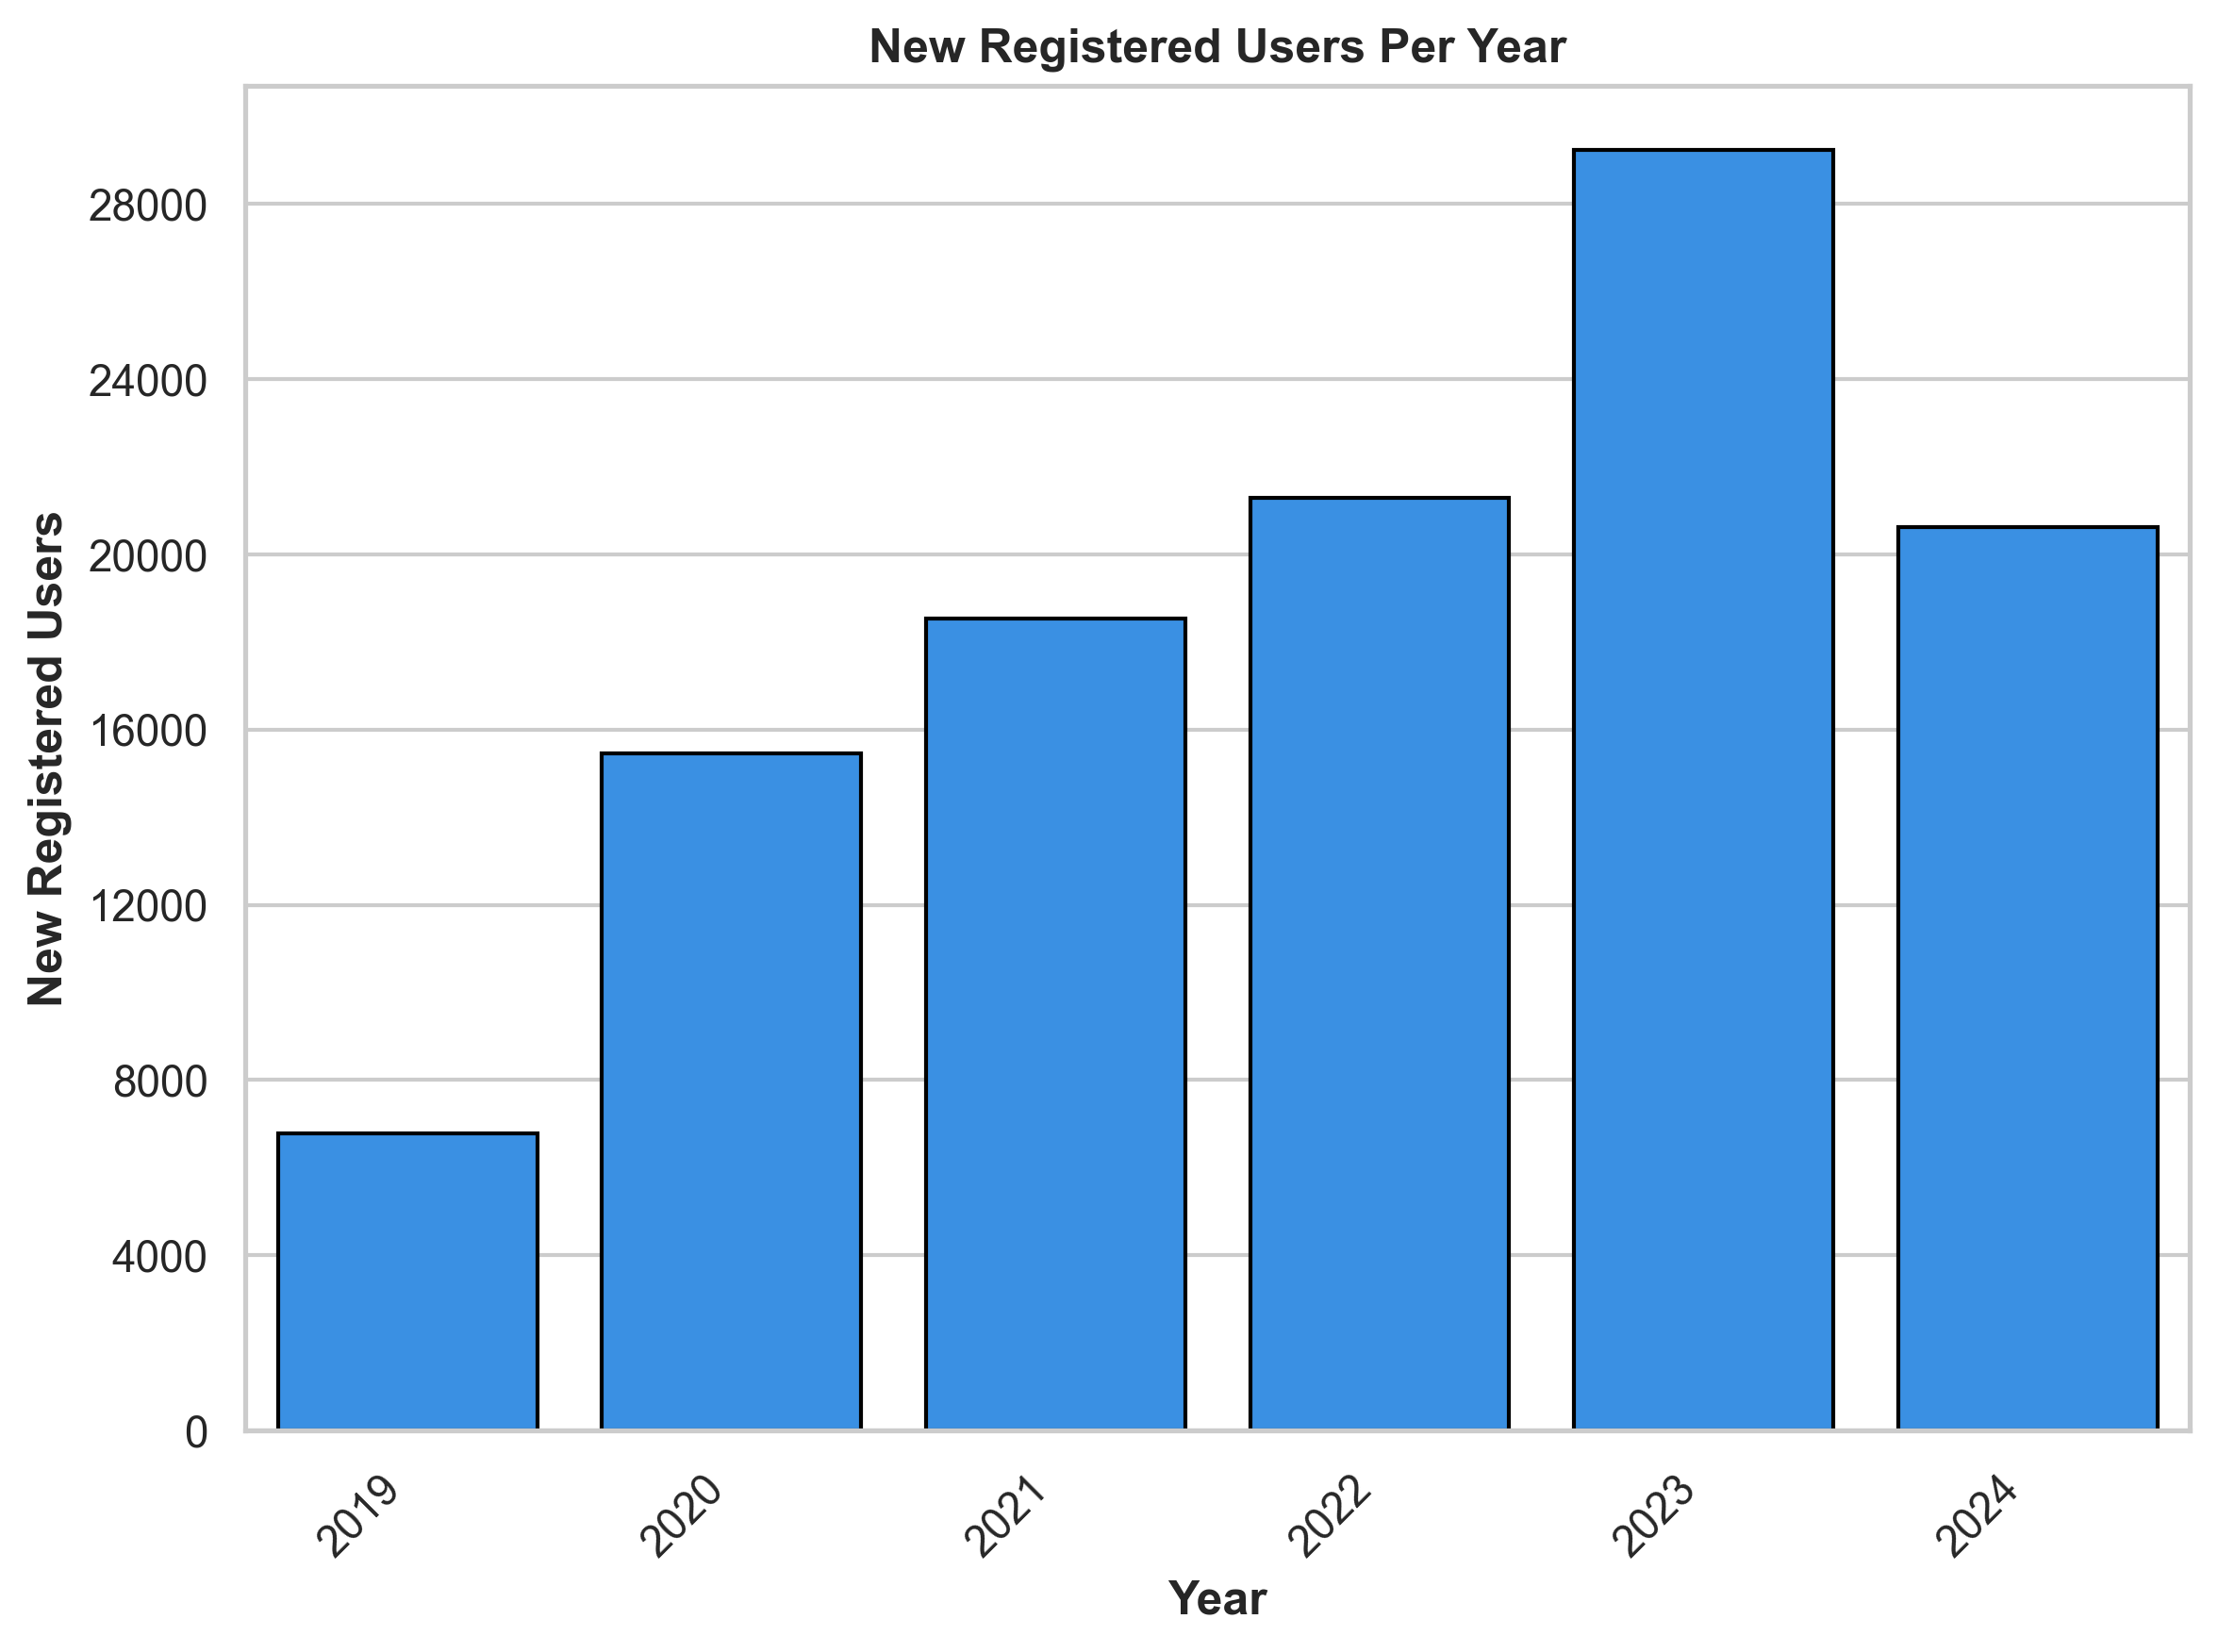

In [241]:
# Create the bar plot using Seaborn
plt.figure(figsize=(8, 6), dpi=300)

# Plotting with Seaborn
ax = sns.barplot(x="year", y="count", data=users_per_year, color=fig_bar_color, edgecolor=fig_edgecolor)

# Add labels and title with appropriate sizes
ax.set_xlabel("Year", fontsize=fig_axis_fontsize, fontweight='bold')
ax.set_ylabel("New Registered Users", fontsize=fig_axis_fontsize, fontweight='bold')
ax.set_title("New Registered Users Per Year", fontsize=fig_title_fontsize, fontweight='bold')

# Rotate x-ticks for better readability
plt.xticks(rotation=45, ha='right')

# Ensure y-ticks are integers and do not overlap
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Apply a tight layout to ensure everything fits well
plt.tight_layout()

# Save the figure as a high-quality image
plt.savefig('new_users_per_year.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


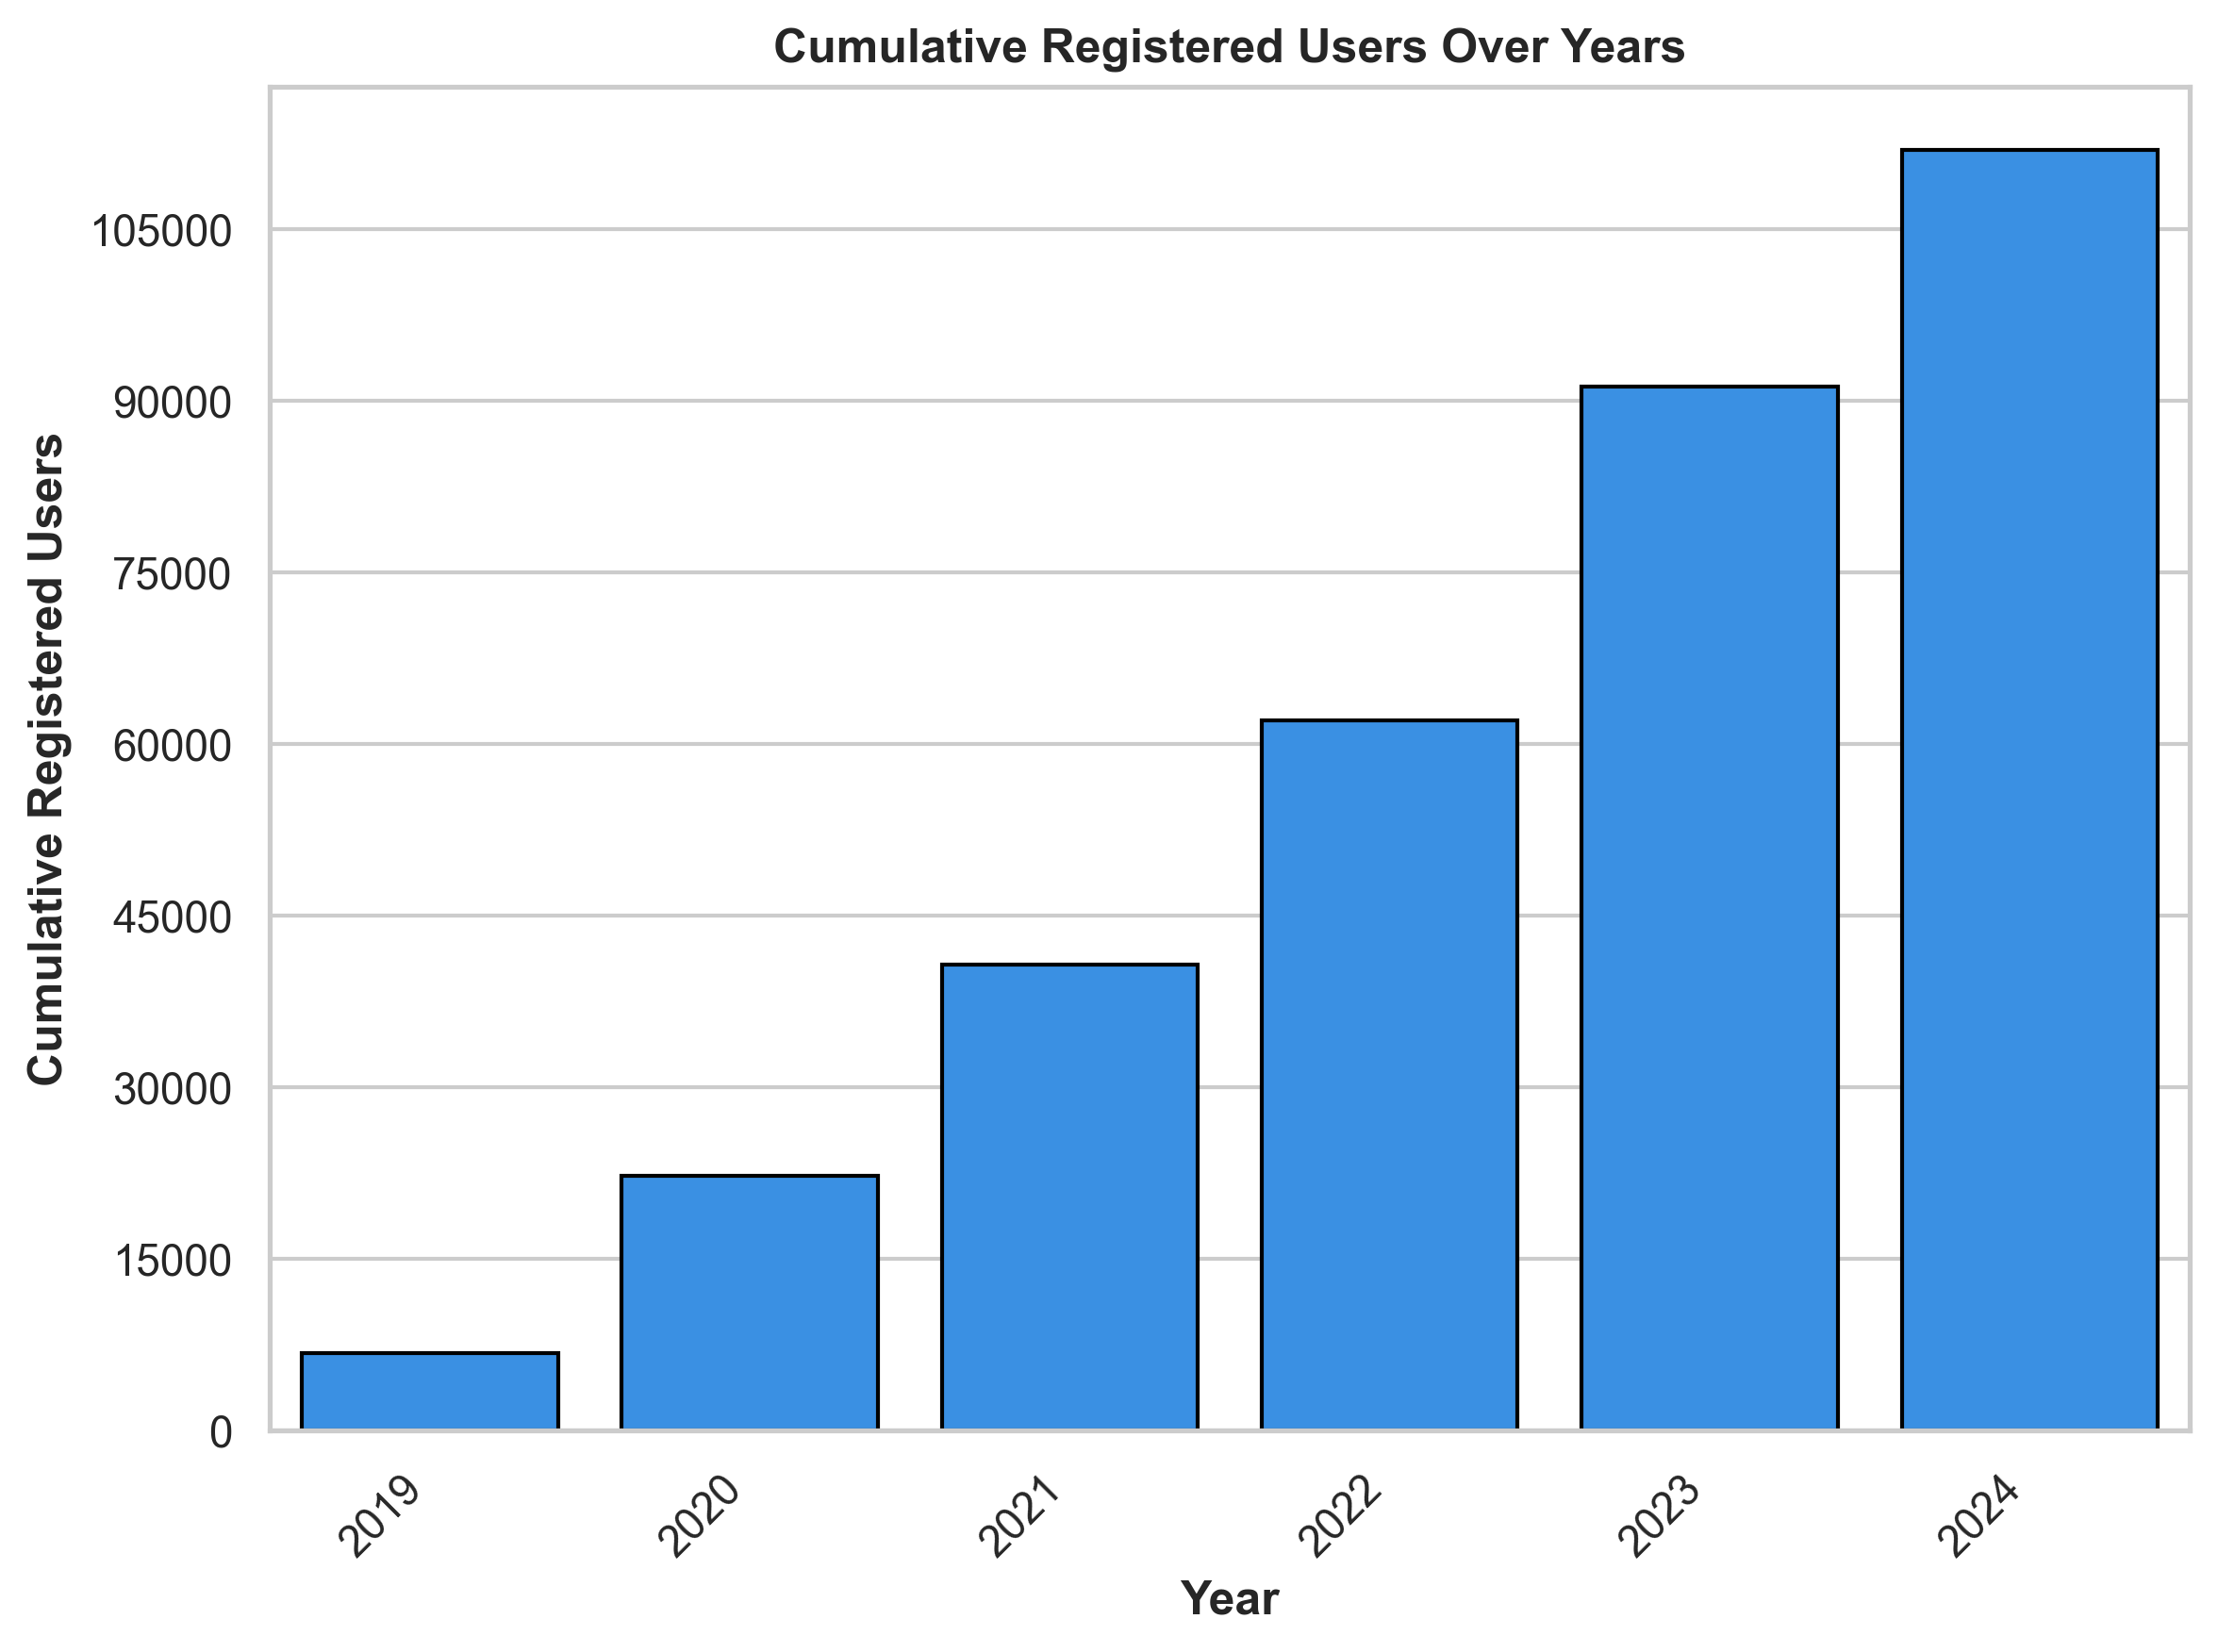

In [243]:
# Calculate the cumulative sum of new users per year
users_per_year['cumulative_count'] = users_per_year['count'].cumsum()

# Create the bar plot using Seaborn
plt.figure(figsize=(8, 6), dpi=300)

# Plotting the cumulative data with Seaborn
ax = sns.barplot(x="year", y="cumulative_count", data=users_per_year, color=fig_bar_color, edgecolor=fig_edgecolor)

# Add labels and title with appropriate sizes
ax.set_xlabel("Year", fontsize=fig_axis_fontsize, fontweight='bold')
ax.set_ylabel("Cumulative Registered Users", fontsize=fig_axis_fontsize, fontweight='bold')
ax.set_title("Cumulative Registered Users Over Years", fontsize=fig_title_fontsize, fontweight='bold')

# Rotate x-ticks for better readability
plt.xticks(rotation=45, ha='right')

# Ensure y-ticks are integers and do not overlap
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Apply a tight layout to ensure everything fits well
plt.tight_layout()

# Save the figure as a high-quality image
plt.savefig('cumulative_users_per_year.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

### Number of credentialed users

In [245]:
# Convert 'join_date' to datetime if it's not already
users['join_date'] = pd.to_datetime(users['join_date'], errors='coerce')

# Filter the DataFrame for credentialed users using .loc[]
credentialed_users = users.loc[users['credentialing_status'] == "Credentialed"].copy()

# Extract the year from 'join_date' and create a new column 'year' using .loc[]
credentialed_users.loc[:, 'year'] = credentialed_users['join_date'].dt.year

# Group by 'year' and count the number of users per year
credentialed_users_per_year = credentialed_users.groupby('year').agg(count=('user_id', 'size')).reset_index()

credentialed_users_per_year.head(3)

,year,count
0,2019,3608
1,2020,7788
2,2021,7847


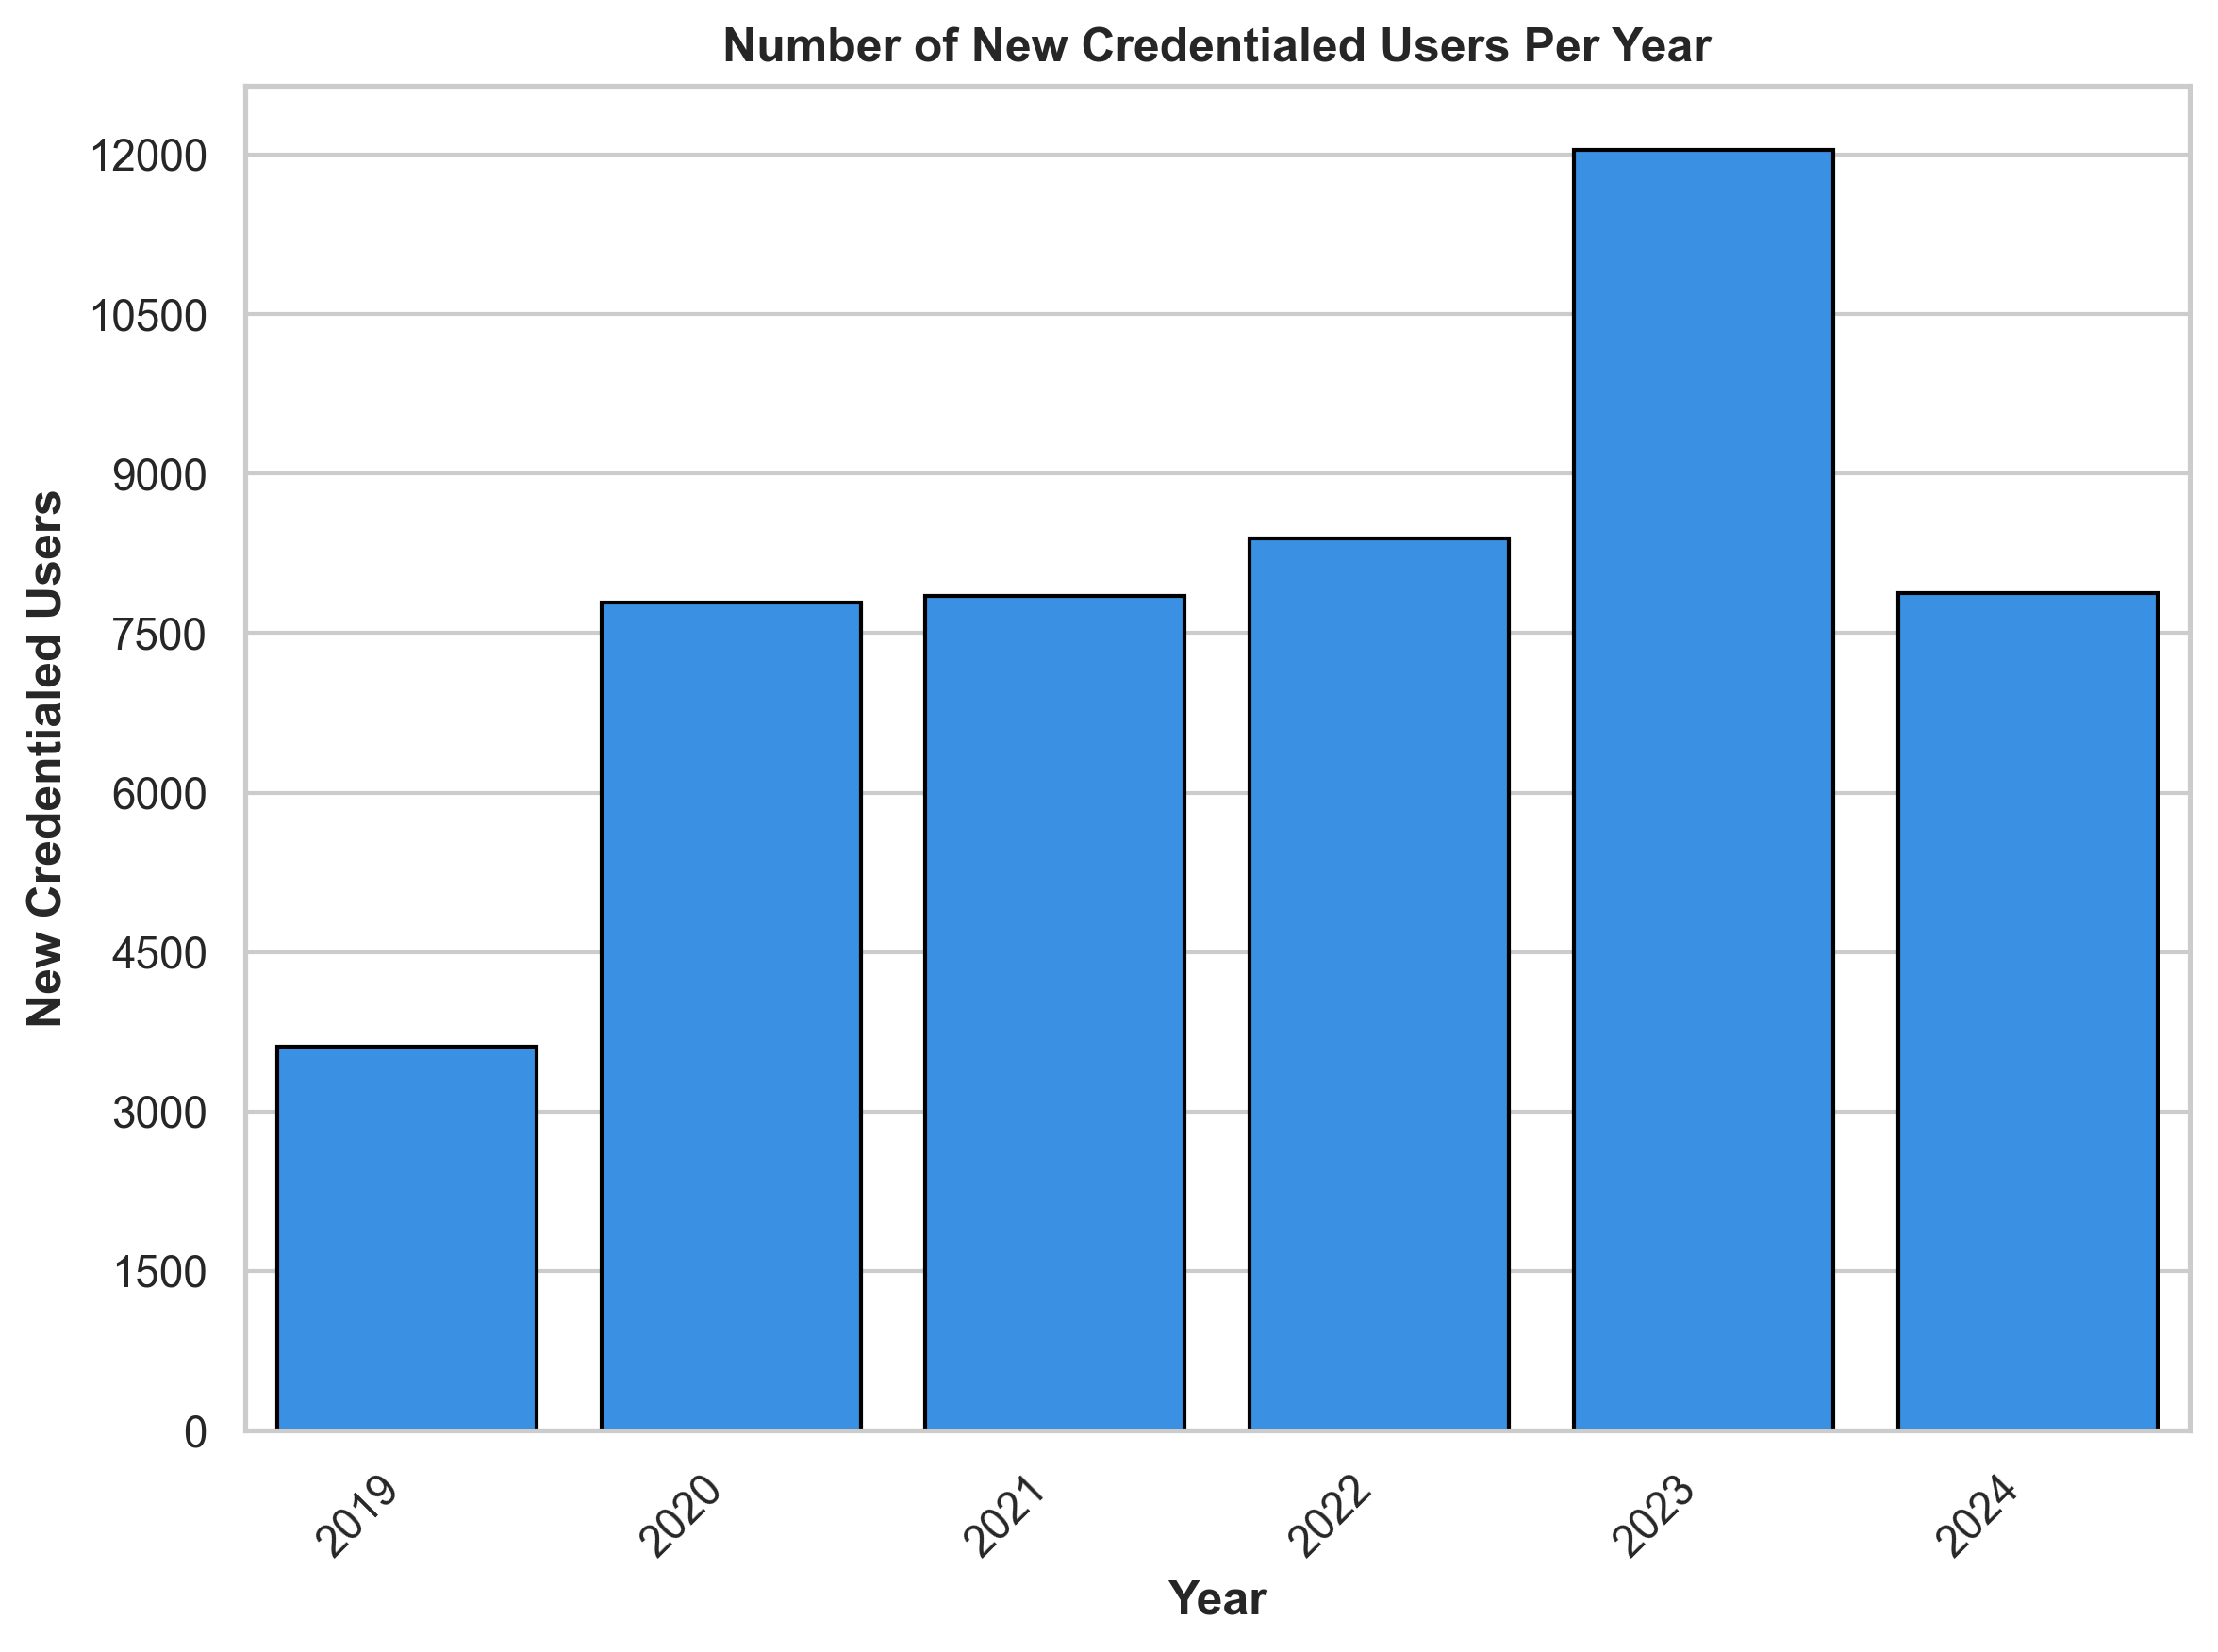

In [249]:
# Create the bar plot using Seaborn
plt.figure(figsize=(8, 6), dpi=300)

# Plotting with Seaborn
ax = sns.barplot(x="year", y="count", data=credentialed_users_per_year, color=fig_bar_color, edgecolor=fig_edgecolor)

# Add labels and title with appropriate sizes
ax.set_xlabel("Year", fontsize=fig_axis_fontsize, fontweight='bold')
ax.set_ylabel("New Credentialed Users", fontsize=fig_axis_fontsize, fontweight='bold')
ax.set_title("Number of New Credentialed Users Per Year", fontsize=fig_title_fontsize, fontweight='bold')

# Rotate x-ticks for better readability
plt.xticks(rotation=45, ha='right')

# Ensure y-ticks are integers and do not overlap
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Apply a tight layout to ensure everything fits well
plt.tight_layout()

# Save the figure as a high-quality image
plt.savefig('new_credentialed_users_per_year.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

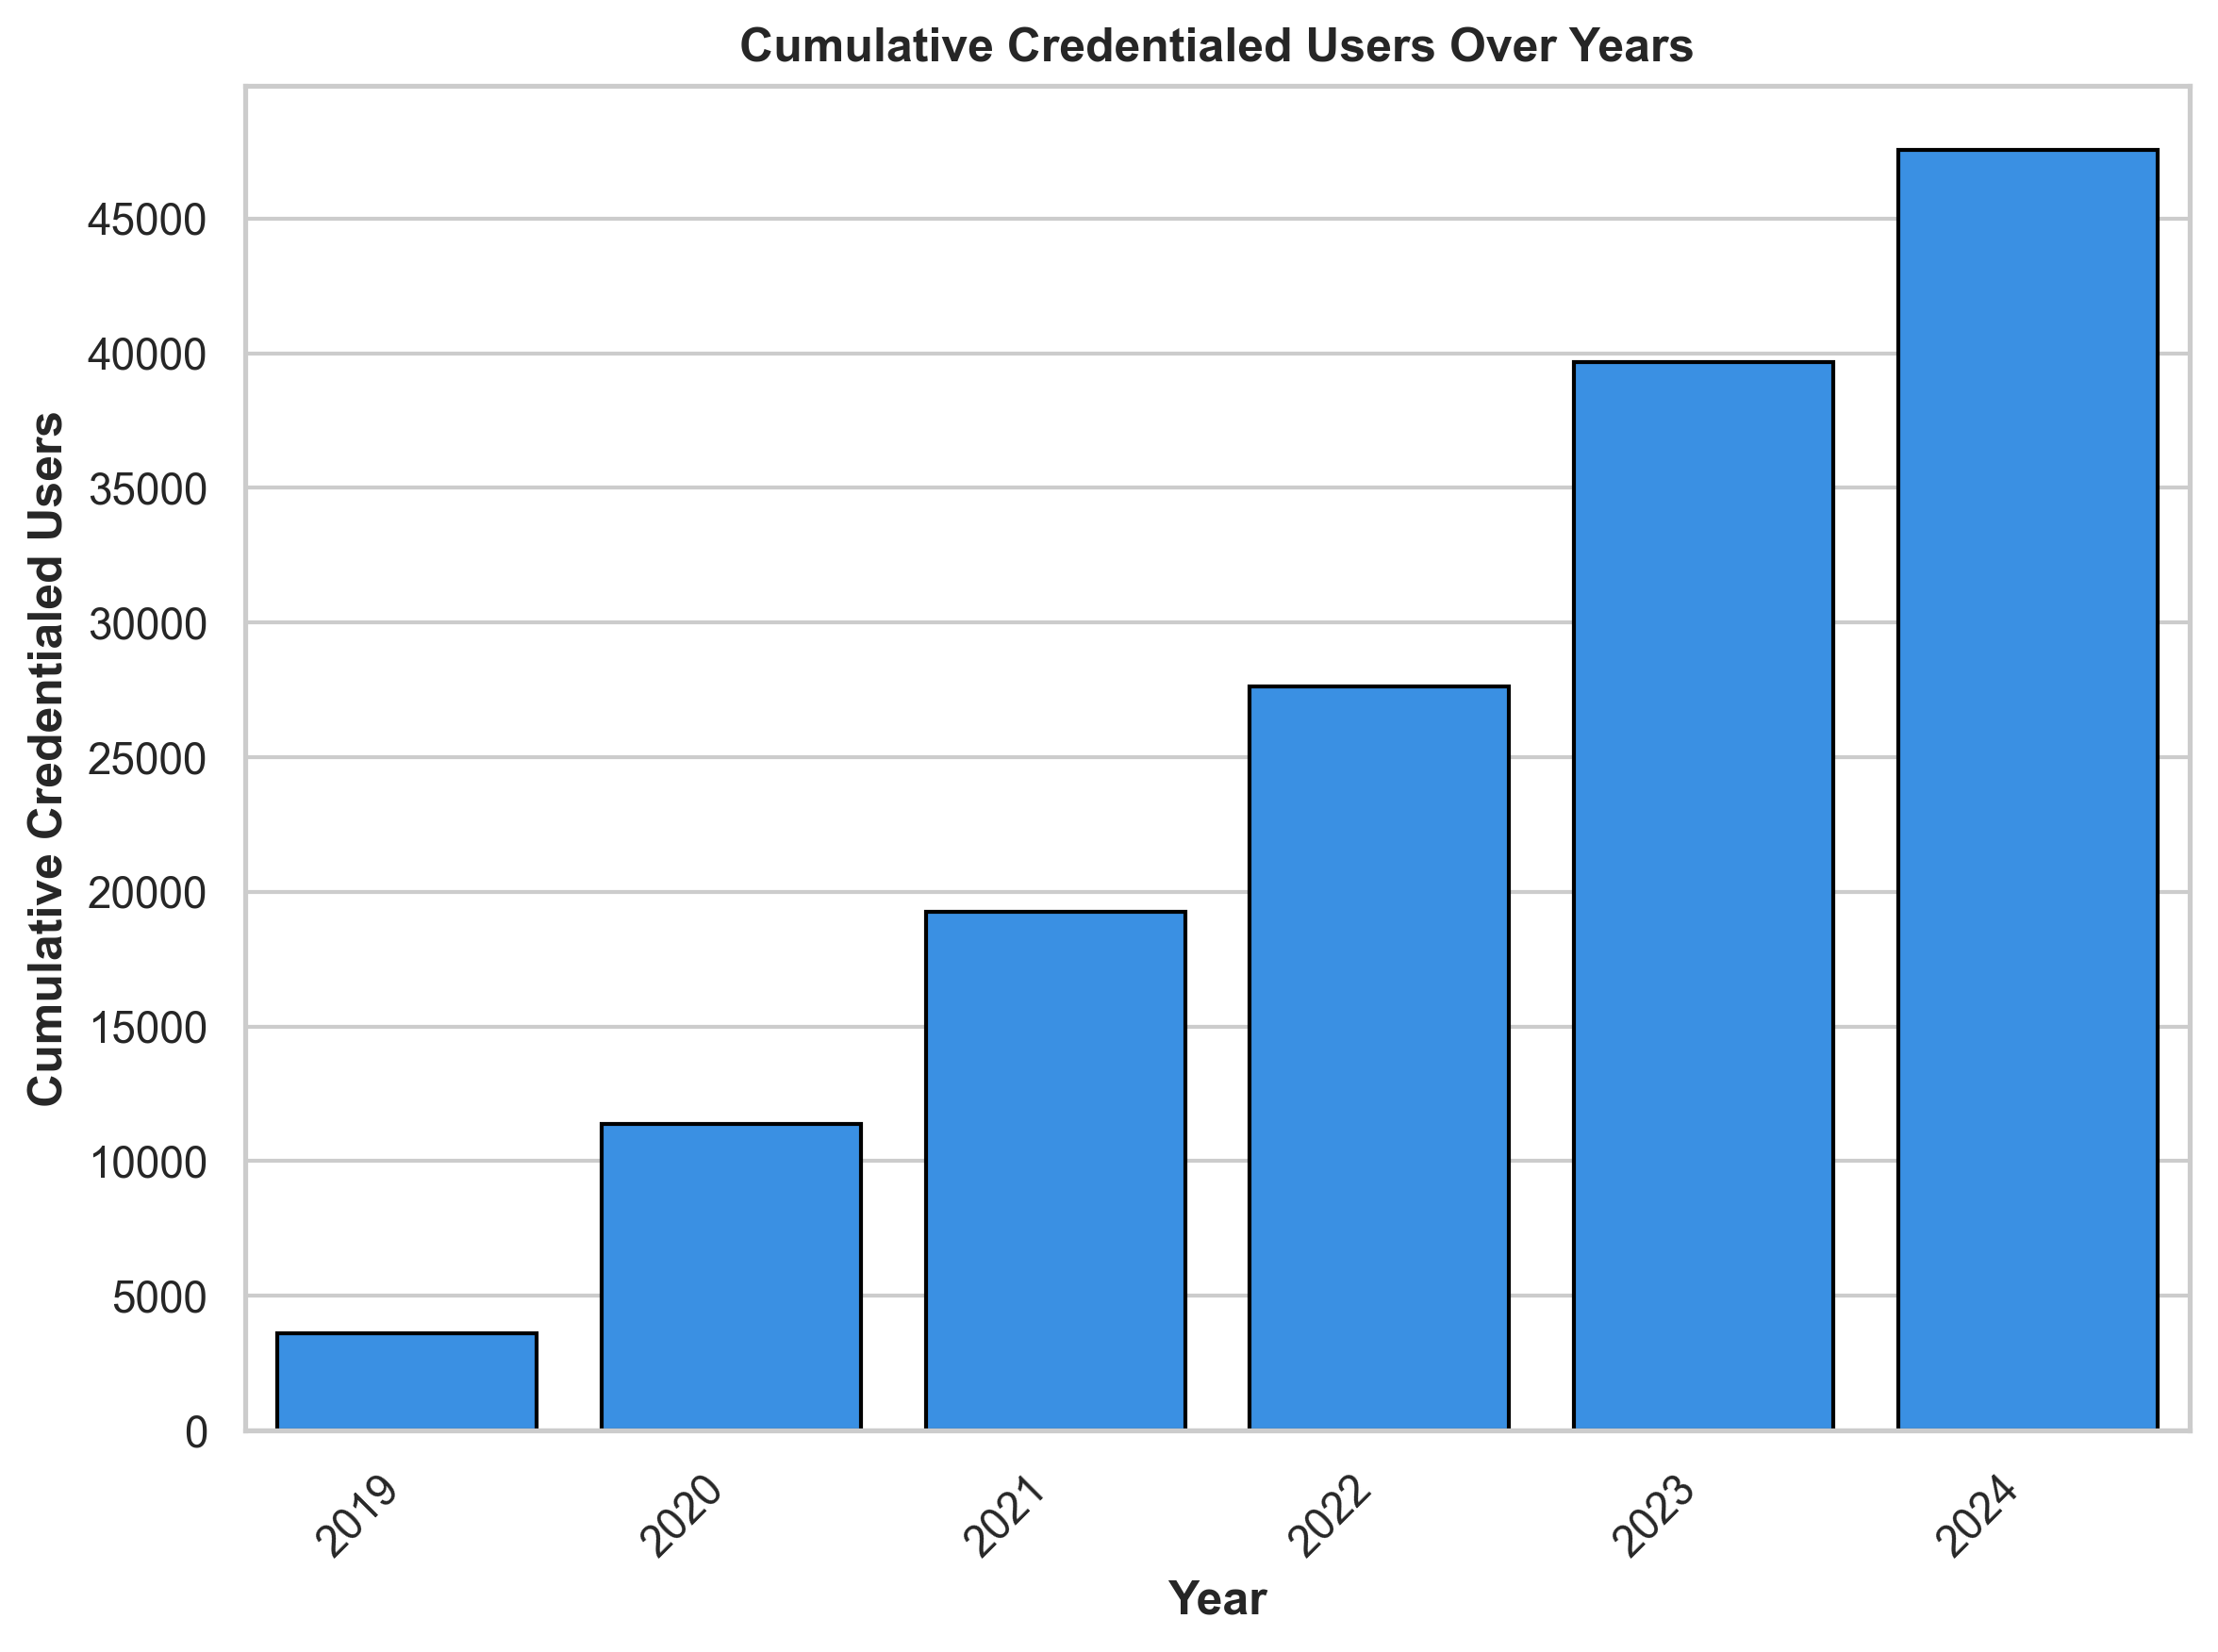

In [251]:
# Calculate the cumulative sum of new users per year
credentialed_users_per_year['cumulative_count'] = credentialed_users_per_year['count'].cumsum()

# Create the bar plot using Seaborn
plt.figure(figsize=(8, 6), dpi=300)

# Plotting the cumulative data with Seaborn
ax = sns.barplot(x="year", y="cumulative_count", data=credentialed_users_per_year, color=fig_bar_color, edgecolor=fig_edgecolor)

# Add labels and title with appropriate sizes
ax.set_xlabel("Year", fontsize=fig_axis_fontsize, fontweight='bold')
ax.set_ylabel("Cumulative Credentialed Users", fontsize=fig_axis_fontsize, fontweight='bold')
ax.set_title("Cumulative Credentialed Users Over Years", fontsize=fig_title_fontsize, fontweight='bold')

# Rotate x-ticks for better readability
plt.xticks(rotation=45, ha='right')

# Ensure y-ticks are integers and do not overlap
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Apply a tight layout to ensure everything fits well
plt.tight_layout()

# Save the figure as a high-quality image
plt.savefig('cumulative_credentialed_users_per_year.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

### Number of published projects over time

In [247]:
# Convert 'publish_date' to datetime if it's not already
projects['publish_date'] = pd.to_datetime(projects['publish_date'], errors='coerce')

# Extract the year from 'publish_date' and create a new column 'year'
projects['year'] = projects['publish_date'].dt.year

# Group by 'year' and count the number of projects per year
projects_per_year = projects.groupby('year').agg(count=('project_id', 'size')).reset_index()

projects_per_year.head(3)

,year,count
0,1999,12
1,2000,11
2,2001,8


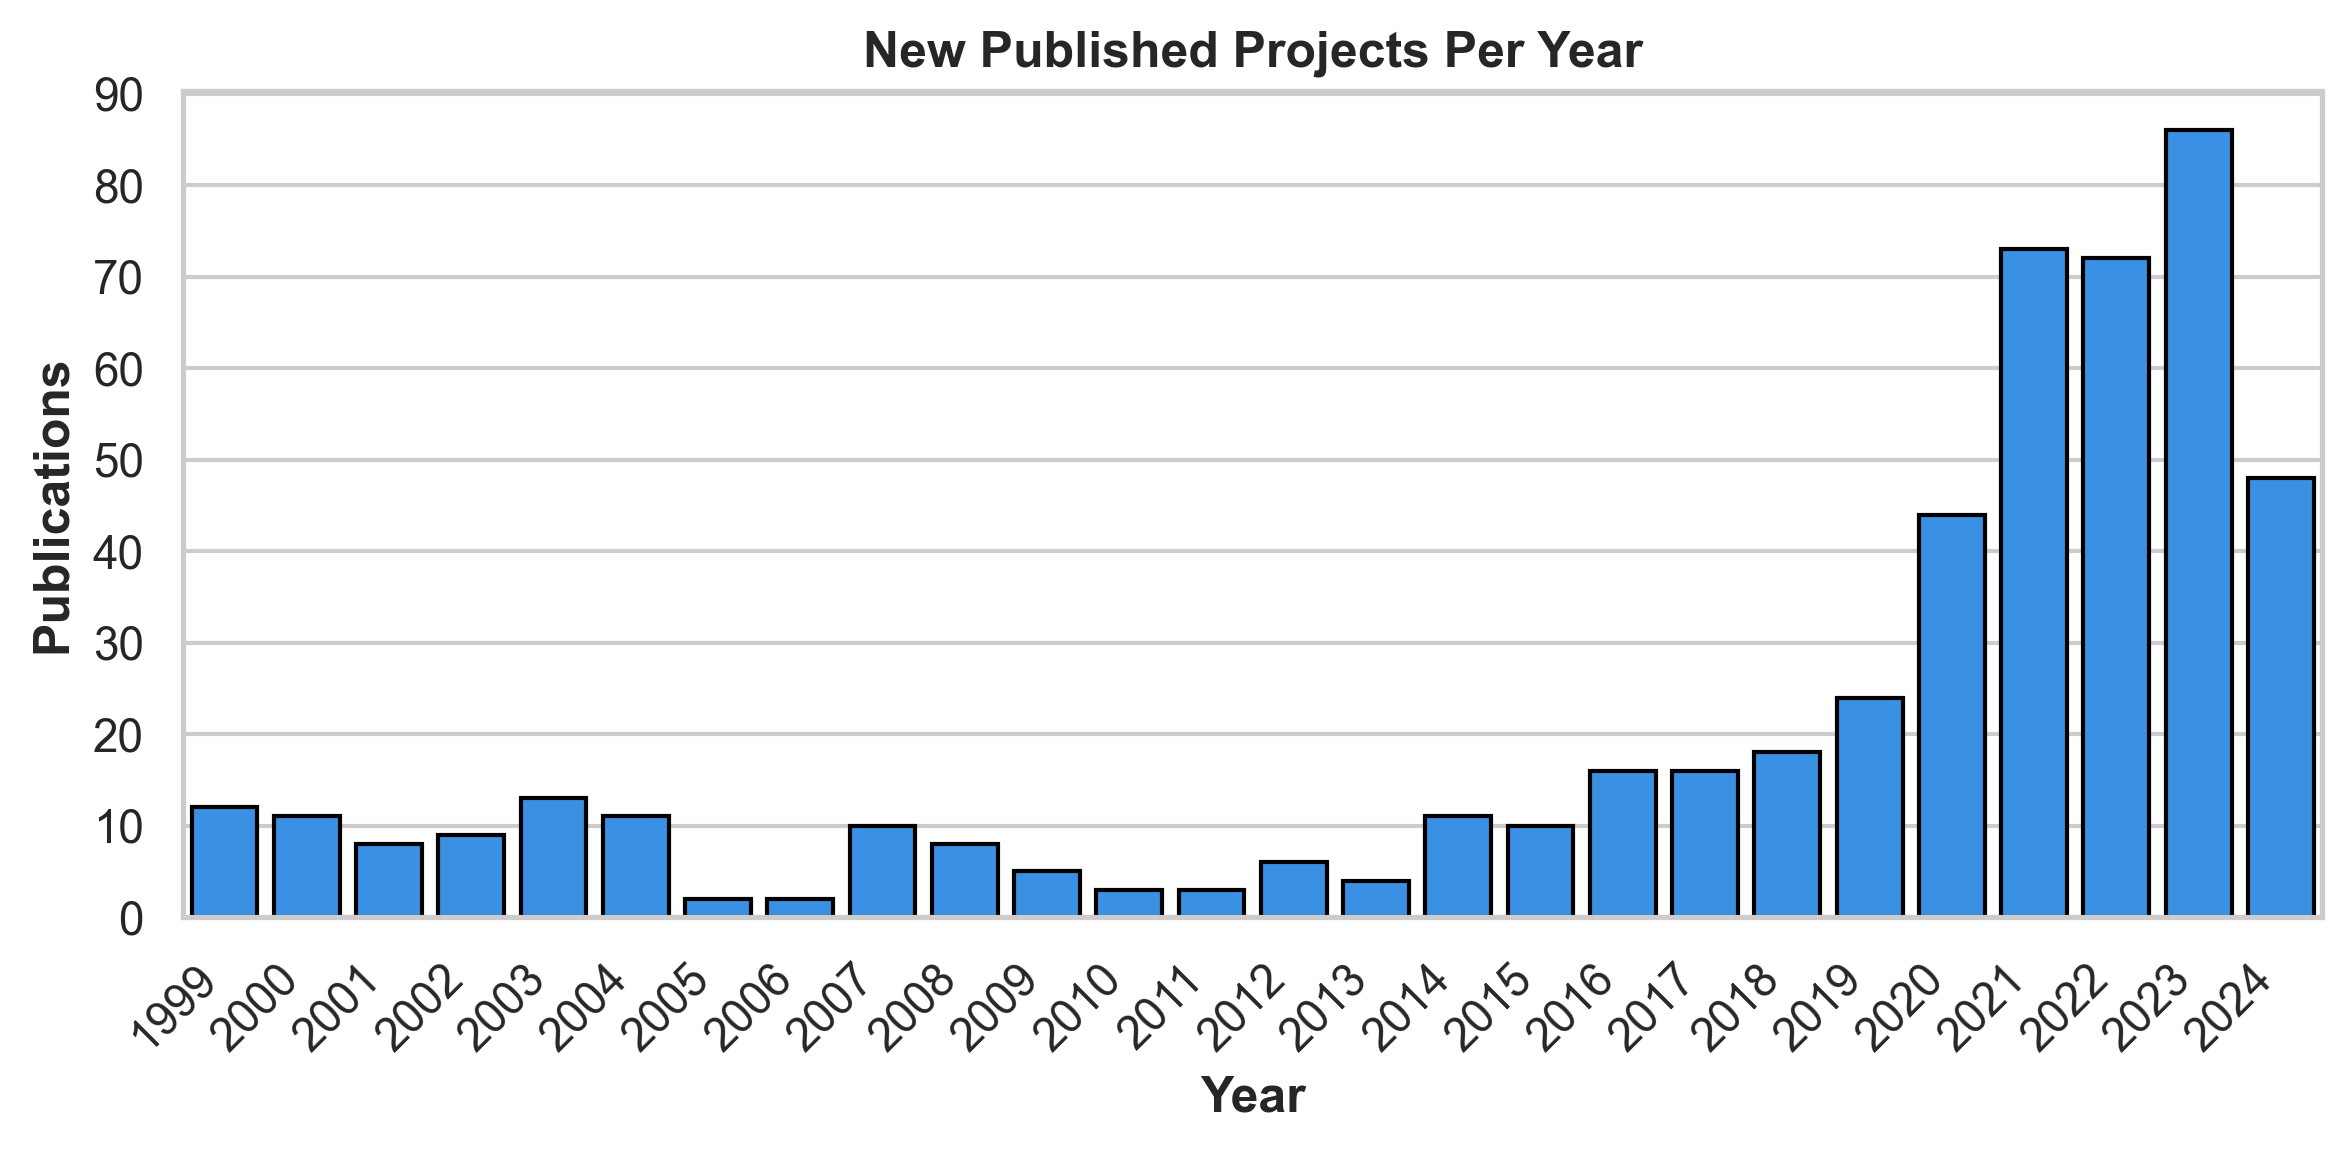

In [253]:
# Create the bar plot using Seaborn
plt.figure(figsize=(8, 4), dpi=300)

# Use Seaborn's barplot
ax = sns.barplot(x="year", y="count", data=projects_per_year, color=fig_bar_color, edgecolor=fig_edgecolor)

# Add labels and title with appropriate sizes
ax.set_xlabel("Year", fontsize=fig_axis_fontsize, fontweight='bold')
ax.set_ylabel("Publications", fontsize=fig_axis_fontsize, fontweight='bold')
ax.set_title("New Published Projects Per Year", fontsize=fig_title_fontsize, fontweight='bold')

# Rotate x-ticks
plt.xticks(rotation=45, ha='right')  # This replaces set_xticklabels and correctly rotates the labels

# Ensure y-ticks do not overlap by setting a more appropriate scale
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Ensures only integer labels are used

# Tight layout for better spacing
plt.tight_layout()

# Save the figure as a high-quality image
plt.savefig('new_published_projects_per_year.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()


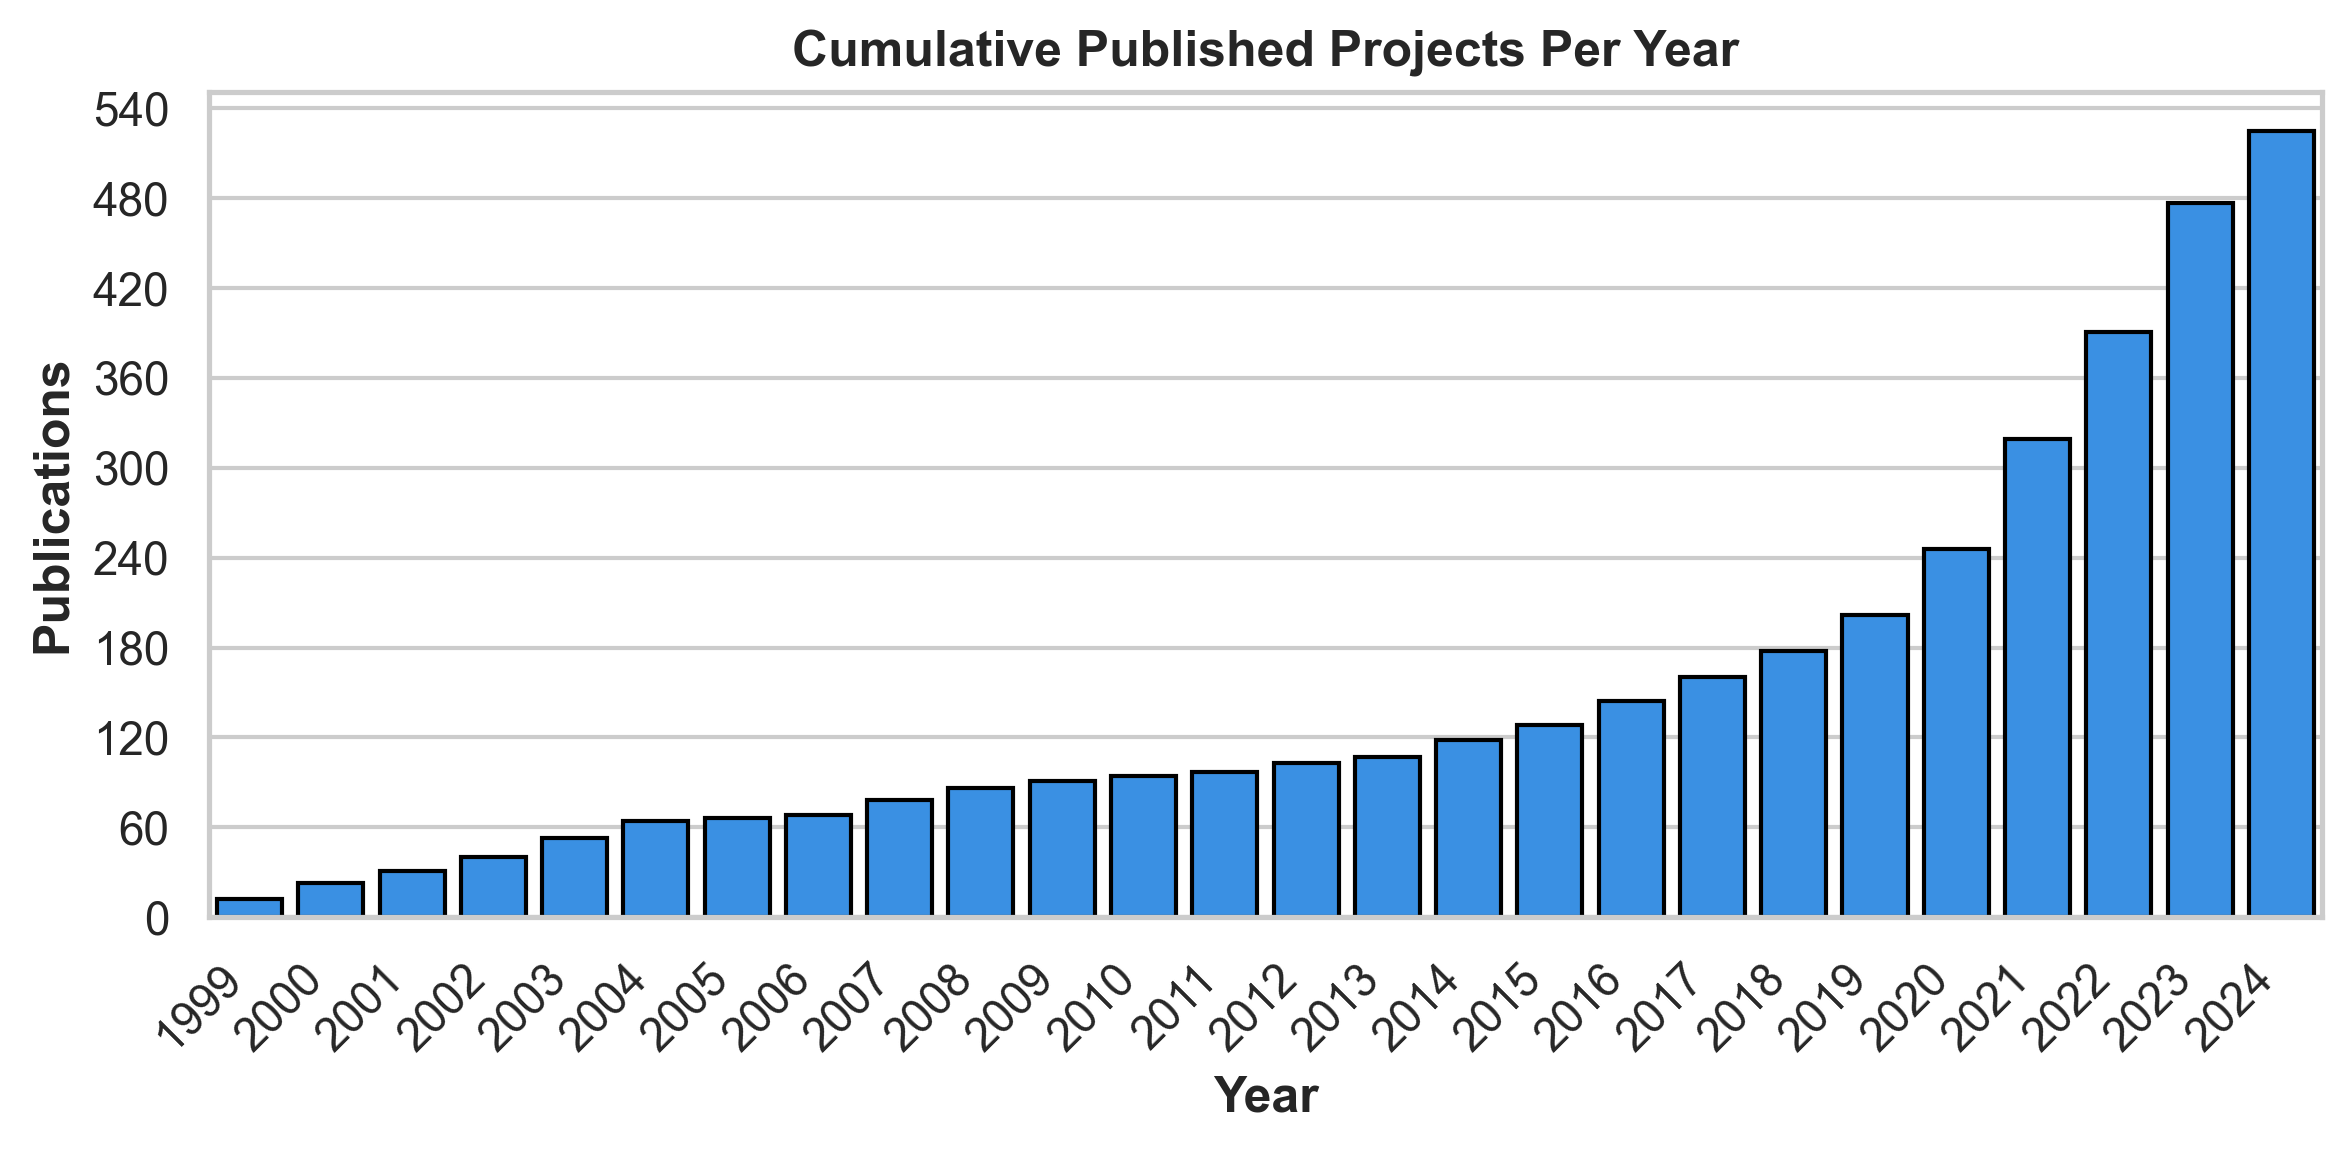

In [254]:
# cumulative projects
projects_per_year['cumulative_count'] = projects_per_year['count'].cumsum()

# Create the bar plot using Seaborn
plt.figure(figsize=(8, 4), dpi=300)

# Use Seaborn's barplot
ax = sns.barplot(x="year", y="cumulative_count", data=projects_per_year, color=fig_bar_color, edgecolor=fig_edgecolor)

# Add labels and title with appropriate sizes
ax.set_xlabel("Year", fontsize=fig_axis_fontsize, fontweight='bold')
ax.set_ylabel("Publications", fontsize=fig_axis_fontsize, fontweight='bold')
ax.set_title("Cumulative Published Projects", fontsize=fig_title_fontsize, fontweight='bold')

# Rotate x-ticks
plt.xticks(rotation=45, ha='right')  # This replaces set_xticklabels and correctly rotates the labels

# Ensure y-ticks do not overlap by setting a more appropriate scale
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # Ensures only integer labels are used

# Tight layout for better spacing
plt.tight_layout()

# Save the figure as a high-quality image
plt.savefig('cumulative_published_projects_per_year.png', dpi=300, bbox_inches='tight')

# Show the plot
plt.show()

### Number of projects submitted by year since 2020

Need to add submitted projects to the system

### OTHERS

- Proportion of projects accepted
- Breakdown by project type?
- Proportion of conference/journal papers that use PhysioNet data/software
- Volume of data that we are hosting
- Number of users signing DUA
- Average daily visits
- Average monthly users (visits)
- New Google Scholar articles citing
- Number of courses
- Number of patents
- Indication that what we are doing is useful
- Stanford paper on shaky foundations (PhysioNet supports a whole field of research)
- Number of datathons/workshops [Chrystinne]
- International reach (users and contributors)
- Who is contributing? What proportion are NIH funded. Providing a mechanism for NIH funded projects to share
- Number of journals referencing PhysioNet as recommended repository
- Analysis of emails. What is the topic? Etc.
